# Student Exam Score Prediction Using Behavioral and Academic Factors

# Importing the Dataset

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
import kagglehub

In [5]:
df = pd.read_csv('student_performance_dataset.csv')

In [6]:
df

,student_id,age,gender,city_type,study_hours_per_day,deep_work_sessions,assignment_completion_rate,attendance_percentage,social_media_hours,doomscrolling_before_sleep,...,family_support,financial_stress,learning_style,career_goal,productivity_after_midnight,revision_efficiency,burnout_risk,consistency_score,final_exam_score,performance_category
0,0,21,Female,Semi-Urban,3.2,7,100,70,3.8,0,...,10,6,Audio,Engineering,9,1,10,3,32,Low
1,1,19,Female,Semi-Urban,3.9,2,46,70,2.6,1,...,2,6,Practical,Business,6,10,4,6,59,Medium
2,2,16,Female,Urban,4.3,7,54,57,4.3,1,...,1,9,Visual,Engineering,7,9,8,1,34,Low
3,3,19,Male,Semi-Urban,5.3,1,78,90,1.7,0,...,5,10,Reading,Medical,7,7,9,10,60,Medium
4,4,17,Female,Urban,4.1,3,100,81,2.6,0,...,5,6,Visual,Medical,4,10,7,9,77,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,2995,22,Female,Rural,2.4,0,40,83,1.0,0,...,10,2,Practical,Arts,9,10,7,9,45,Low
2996,2996,19,Female,Urban,5.2,7,94,100,1.4,0,...,1,10,Visual,Medical,5,3,7,9,100,High
2997,2997,23,Female,Rural,5.9,2,41,86,5.4,1,...,7,10,Practical,Engineering,6,8,10,10,50,Medium
2998,2998,17,Male,Urban,3.9,1,92,96,2.8,1,...,3,10,Practical,Medical,4,7,1,4,76,High


# Removing Not Necessary Columns

In [7]:
df1 = df.drop(["student_id","performance_category"], axis = 1)

In [8]:
(df1.isnull().sum()/df1.count())*100

age                            0.000000
gender                         0.000000
city_type                      0.000000
study_hours_per_day            0.000000
deep_work_sessions             0.000000
assignment_completion_rate     0.000000
attendance_percentage          0.000000
social_media_hours             2.040816
doomscrolling_before_sleep     0.000000
notification_distractions      0.000000
ai_tool_usage_hours            0.000000
gaming_hours                   0.000000
stress_level                   0.000000
motivation_level               0.000000
focus_score                    2.040816
procrastination_index          0.000000
mental_state                   0.000000
sleep_hours                    2.040816
caffeine_intake                0.000000
physical_activity_hours        0.000000
internet_quality               0.000000
family_support                 0.000000
financial_stress               0.000000
learning_style                 0.000000
career_goal                    0.000000


In [9]:
df1.columns

Index(['age', 'gender', 'city_type', 'study_hours_per_day',
       'deep_work_sessions', 'assignment_completion_rate',
       'attendance_percentage', 'social_media_hours',
       'doomscrolling_before_sleep', 'notification_distractions',
       'ai_tool_usage_hours', 'gaming_hours', 'stress_level',
       'motivation_level', 'focus_score', 'procrastination_index',
       'mental_state', 'sleep_hours', 'caffeine_intake',
       'physical_activity_hours', 'internet_quality', 'family_support',
       'financial_stress', 'learning_style', 'career_goal',
       'productivity_after_midnight', 'revision_efficiency', 'burnout_risk',
       'consistency_score', 'final_exam_score'],
      dtype='object')

# Filling Missing Values

In [10]:
mean_smh = df1["social_media_hours"].mean()
df1["social_media_hours"] = df1["social_media_hours"].fillna(mean_smh)
df1.isnull().sum()

age                             0
gender                          0
city_type                       0
study_hours_per_day             0
deep_work_sessions              0
assignment_completion_rate      0
attendance_percentage           0
social_media_hours              0
doomscrolling_before_sleep      0
notification_distractions       0
ai_tool_usage_hours             0
gaming_hours                    0
stress_level                    0
motivation_level                0
focus_score                    60
procrastination_index           0
mental_state                    0
sleep_hours                    60
caffeine_intake                 0
physical_activity_hours         0
internet_quality                0
family_support                  0
financial_stress                0
learning_style                  0
career_goal                     0
productivity_after_midnight     0
revision_efficiency             0
burnout_risk                    0
consistency_score               0
final_exam_sco

In [11]:
mean_sh = df1["sleep_hours"].mean()
df1["sleep_hours"] = df1["sleep_hours"].fillna(mean_sh)
mean_fs = df1["focus_score"].mean()
df1["focus_score"] = df1["focus_score"].fillna(mean_fs)
df1.isnull().sum()

age                            0
gender                         0
city_type                      0
study_hours_per_day            0
deep_work_sessions             0
assignment_completion_rate     0
attendance_percentage          0
social_media_hours             0
doomscrolling_before_sleep     0
notification_distractions      0
ai_tool_usage_hours            0
gaming_hours                   0
stress_level                   0
motivation_level               0
focus_score                    0
procrastination_index          0
mental_state                   0
sleep_hours                    0
caffeine_intake                0
physical_activity_hours        0
internet_quality               0
family_support                 0
financial_stress               0
learning_style                 0
career_goal                    0
productivity_after_midnight    0
revision_efficiency            0
burnout_risk                   0
consistency_score              0
final_exam_score               0
dtype: int

# Plotting QQ_Plots

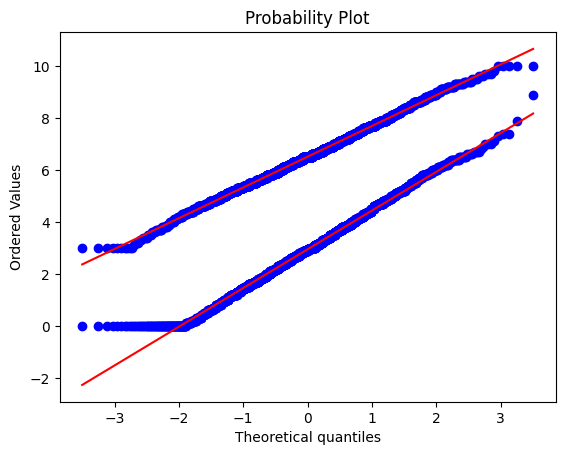

In [12]:
import scipy.stats as stats
stats.probplot(df1["social_media_hours"],dist = "norm", plot = plt)
stats.probplot(df1["sleep_hours"],dist = "norm", plot = plt)
plt.show()

In [3]:
stats.probplot(df1["social_media_hours"],dist = "norm", plot = plt)

NameError: name 'df1' is not defined

((array([-3.50184707, -3.25811987, -3.12333914, ...,  3.12333914,
          3.25811987,  3.50184707], shape=(3000,)),
  array([ 3.,  3.,  3., ..., 10., 10., 10.], shape=(3000,))),
 (np.float64(1.1838293767095298),
  np.float64(6.510306122448981),
  np.float64(0.9991490435358882)))

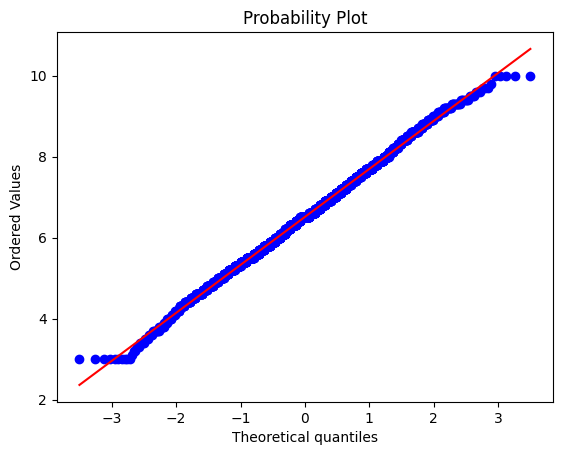

In [11]:
stats.probplot(df1["sleep_hours"],dist = "norm", plot = plt)

In [12]:
df1

,age,gender,city_type,study_hours_per_day,deep_work_sessions,assignment_completion_rate,attendance_percentage,social_media_hours,doomscrolling_before_sleep,notification_distractions,...,internet_quality,family_support,financial_stress,learning_style,career_goal,productivity_after_midnight,revision_efficiency,burnout_risk,consistency_score,final_exam_score
0,21,Female,Semi-Urban,3.2,7,100,70,3.8,0,107,...,1,10,6,Audio,Engineering,9,1,10,3,32
1,19,Female,Semi-Urban,3.9,2,46,70,2.6,1,93,...,4,2,6,Practical,Business,6,10,4,6,59
2,16,Female,Urban,4.3,7,54,57,4.3,1,82,...,9,1,9,Visual,Engineering,7,9,8,1,34
3,19,Male,Semi-Urban,5.3,1,78,90,1.7,0,27,...,1,5,10,Reading,Medical,7,7,9,10,60
4,17,Female,Urban,4.1,3,100,81,2.6,0,8,...,9,5,6,Visual,Medical,4,10,7,9,77
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,22,Female,Rural,2.4,0,40,83,1.0,0,71,...,5,10,2,Practical,Arts,9,10,7,9,45
2996,19,Female,Urban,5.2,7,94,100,1.4,0,114,...,3,1,10,Visual,Medical,5,3,7,9,100
2997,23,Female,Rural,5.9,2,41,86,5.4,1,88,...,5,7,10,Practical,Engineering,6,8,10,10,50
2998,17,Male,Urban,3.9,1,92,96,2.8,1,94,...,7,3,10,Practical,Medical,4,7,1,4,76


# Describe function to see the stats for the dataset

In [13]:
df1.describe()

,age,study_hours_per_day,deep_work_sessions,assignment_completion_rate,attendance_percentage,social_media_hours,doomscrolling_before_sleep,notification_distractions,ai_tool_usage_hours,gaming_hours,...,caffeine_intake,physical_activity_hours,internet_quality,family_support,financial_stress,productivity_after_midnight,revision_efficiency,burnout_risk,consistency_score,final_exam_score
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,...,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,19.030333,3.988767,3.511667,69.926333,74.558000,2.949422,0.493000,61.961667,1.538933,2.053600,...,3.500333,1.054167,5.552000,5.467667,5.556667,5.546333,5.446000,5.535000,5.512333,54.795667
std,2.553217,1.503377,2.297743,17.562794,14.473048,1.495121,0.500034,33.125156,0.925619,1.386622,...,2.274436,0.725919,2.906564,2.856047,2.865809,2.864132,2.890421,2.837157,2.860287,18.691309
min,15.000000,0.500000,0.000000,40.000000,50.000000,0.000000,0.000000,5.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,17.000000,2.900000,1.000000,55.000000,62.000000,1.900000,0.000000,32.000000,0.900000,1.000000,...,2.000000,0.500000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,42.000000
50%,19.000000,4.000000,4.000000,70.000000,74.000000,2.949422,0.000000,62.000000,1.500000,2.000000,...,3.000000,1.000000,6.000000,5.000000,6.000000,6.000000,5.000000,6.000000,6.000000,55.000000
75%,21.000000,5.000000,6.000000,85.000000,87.000000,3.925000,1.000000,91.000000,2.100000,3.000000,...,5.000000,1.600000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,67.000000
max,23.000000,8.800000,7.000000,100.000000,100.000000,8.900000,1.000000,119.000000,5.000000,7.100000,...,7.000000,3.900000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,100.000000


# HeatMap to see the correlations visually

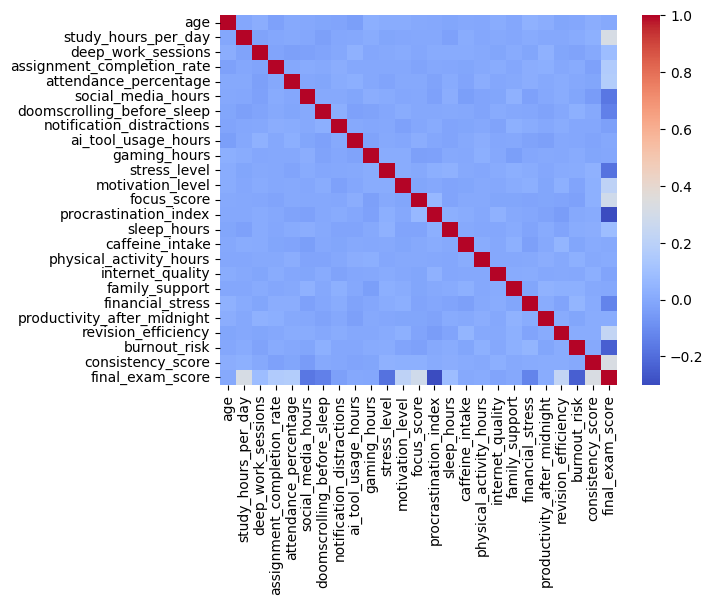

In [14]:
sns.heatmap(df1.corr(numeric_only = True), cmap = "coolwarm")
plt.show()

In [15]:
df1["notification_distractions"]

0       107
1        93
2        82
3        27
4         8
       ... 
2995     71
2996    114
2997     88
2998     94
2999    108
Name: notification_distractions, Length: 3000, dtype: int64

# Encoding (One Hot Encoding)

In [16]:
df1.dtypes

age                              int64
gender                          object
city_type                       object
study_hours_per_day            float64
deep_work_sessions               int64
assignment_completion_rate       int64
attendance_percentage            int64
social_media_hours             float64
doomscrolling_before_sleep       int64
notification_distractions        int64
ai_tool_usage_hours            float64
gaming_hours                   float64
stress_level                     int64
motivation_level                 int64
focus_score                    float64
procrastination_index            int64
mental_state                    object
sleep_hours                    float64
caffeine_intake                  int64
physical_activity_hours        float64
internet_quality                 int64
family_support                   int64
financial_stress                 int64
learning_style                  object
career_goal                     object
productivity_after_midnig

In [17]:
encoded_df1 = pd.get_dummies(df1, columns=['gender','learning_style','career_goal','city_type','mental_state',], drop_first=True)

In [18]:
encoded_df1

,age,study_hours_per_day,deep_work_sessions,assignment_completion_rate,attendance_percentage,social_media_hours,doomscrolling_before_sleep,notification_distractions,ai_tool_usage_hours,gaming_hours,...,learning_style_Visual,career_goal_Business,career_goal_Engineering,career_goal_Medical,career_goal_Research,city_type_Semi-Urban,city_type_Urban,mental_state_Burnout,mental_state_Distracted,mental_state_Focused
0,21,3.2,7,100,70,3.8,0,107,0.6,1.8,...,False,False,True,False,False,True,False,False,False,False
1,19,3.9,2,46,70,2.6,1,93,1.5,1.1,...,False,True,False,False,False,True,False,True,False,False
2,16,4.3,7,54,57,4.3,1,82,0.5,0.0,...,True,False,True,False,False,False,True,True,False,False
3,19,5.3,1,78,90,1.7,0,27,1.4,3.8,...,False,False,False,True,False,True,False,True,False,False
4,17,4.1,3,100,81,2.6,0,8,1.3,2.5,...,True,False,False,True,False,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,22,2.4,0,40,83,1.0,0,71,2.7,2.0,...,False,False,False,False,False,False,False,False,False,False
2996,19,5.2,7,94,100,1.4,0,114,3.2,3.8,...,True,False,False,True,False,False,True,True,False,False
2997,23,5.9,2,41,86,5.4,1,88,0.0,2.9,...,False,False,True,False,False,False,False,False,False,False
2998,17,3.9,1,92,96,2.8,1,94,1.8,2.8,...,False,False,False,True,False,False,True,False,False,True


In [19]:
df1.shape

(3000, 30)

In [20]:
encoded_df1.columns

Index(['age', 'study_hours_per_day', 'deep_work_sessions',
       'assignment_completion_rate', 'attendance_percentage',
       'social_media_hours', 'doomscrolling_before_sleep',
       'notification_distractions', 'ai_tool_usage_hours', 'gaming_hours',
       'stress_level', 'motivation_level', 'focus_score',
       'procrastination_index', 'sleep_hours', 'caffeine_intake',
       'physical_activity_hours', 'internet_quality', 'family_support',
       'financial_stress', 'productivity_after_midnight',
       'revision_efficiency', 'burnout_risk', 'consistency_score',
       'final_exam_score', 'gender_Male', 'learning_style_Practical',
       'learning_style_Reading', 'learning_style_Visual',
       'career_goal_Business', 'career_goal_Engineering',
       'career_goal_Medical', 'career_goal_Research', 'city_type_Semi-Urban',
       'city_type_Urban', 'mental_state_Burnout', 'mental_state_Distracted',
       'mental_state_Focused'],
      dtype='object')

# Finding Correlation after encoding

In [21]:
corr = encoded_df1.corr(numeric_only=True)
corr["final_exam_score"].sort_values(ascending=False)

final_exam_score               1.000000
consistency_score              0.329144
study_hours_per_day            0.317229
focus_score                    0.284330
mental_state_Focused           0.254380
revision_efficiency            0.230729
motivation_level               0.209093
attendance_percentage          0.172020
assignment_completion_rate     0.159037
deep_work_sessions             0.086185
sleep_hours                    0.081295
career_goal_Medical            0.022628
productivity_after_midnight    0.014107
physical_activity_hours        0.008024
learning_style_Practical       0.006451
career_goal_Research           0.004496
caffeine_intake                0.000743
age                            0.000172
career_goal_Business          -0.001447
ai_tool_usage_hours           -0.003776
family_support                -0.004131
learning_style_Reading        -0.004306
mental_state_Distracted       -0.004923
city_type_Urban               -0.007104
gaming_hours                  -0.010042


In [22]:
encoded_df1.columns

Index(['age', 'study_hours_per_day', 'deep_work_sessions',
       'assignment_completion_rate', 'attendance_percentage',
       'social_media_hours', 'doomscrolling_before_sleep',
       'notification_distractions', 'ai_tool_usage_hours', 'gaming_hours',
       'stress_level', 'motivation_level', 'focus_score',
       'procrastination_index', 'sleep_hours', 'caffeine_intake',
       'physical_activity_hours', 'internet_quality', 'family_support',
       'financial_stress', 'productivity_after_midnight',
       'revision_efficiency', 'burnout_risk', 'consistency_score',
       'final_exam_score', 'gender_Male', 'learning_style_Practical',
       'learning_style_Reading', 'learning_style_Visual',
       'career_goal_Business', 'career_goal_Engineering',
       'career_goal_Medical', 'career_goal_Research', 'city_type_Semi-Urban',
       'city_type_Urban', 'mental_state_Burnout', 'mental_state_Distracted',
       'mental_state_Focused'],
      dtype='object')

# Removing features
## that have very negligible effect on the prediction after doing the linear regression

In [23]:
low_features = [
    'gender_Male',
    'city_type_Urban',
    'city_type_Semi-Urban',
    'career_goal_Business',
    'career_goal_Engineering',
    'career_goal_Medical',
    'career_goal_Research',
    'learning_style_Practical',
    'learning_style_Reading',
    'learning_style_Visual'
]
encoded_df1 = encoded_df1.drop(columns = low_features)

# Train_Test_Split & Standardising the Dataset

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [25]:
X = encoded_df1.drop("final_exam_score",axis = 1)
y = encoded_df1["final_exam_score"]
X.shape

(3000, 27)

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

In [27]:
scaler = StandardScaler()

In [28]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [29]:
X_train_final = pd.DataFrame(X_train_scaled, columns = X_train.columns)
X_test_final = pd.DataFrame(X_test_scaled, columns = X_test.columns)

# Importing Linear Regression

In [30]:
from sklearn.linear_model import LinearRegression

In [31]:
lr = LinearRegression()

## Making the X_train and y_train fit on the Model

In [32]:
lr.fit(X_train_final, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [33]:
y_pred = lr.predict(X_test_final)

# Calculating R2 Score

In [34]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.80826501757578

# Overfitting Check

In [35]:
print("Train R²:", lr.score(X_train_final, y_train))
print("Test R²:", lr.score(X_test_final, y_test))

Train R²: 0.8095657007797391
Test R²: 0.80826501757578


# Finding MAE

In [36]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
print(mae)

6.457762475464872


# Cross_Validation_Score Test

In [37]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

scores = cross_val_score(
    LinearRegression(),
    X,
    y,
    cv=5,
    scoring='r2'
)

print(scores)
print("Mean R²:", scores.mean())
print("Std:", scores.std())

[0.80376007 0.7916381  0.82803875 0.78160113 0.81670542]
Mean R²: 0.8043486948059778
Std: 0.016692899988744275


# Finding the coeffecients(m1, m2, m3.....) and intercept(b) from the model

In [38]:
lr.coef_

array([-0.21154083,  6.05198634,  2.0157817 ,  3.41069302,  2.98005695,
       -3.09093971, -2.39717992, -0.45513515, -0.230076  , -0.04921302,
       -3.59567162,  4.09987425,  5.60791377, -5.78772536,  1.9125645 ,
       -0.10101122,  0.14303858, -0.11526829,  0.2894221 , -2.10269983,
        0.04974823,  4.25685749, -4.14561613,  6.13799145, -4.64715466,
       -0.51801776,  2.99878443])

In [39]:
lr.intercept_

np.float64(54.7625)

In [40]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lr = LinearRegression()
lr.fit(X_scaled, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [41]:
import joblib

In [42]:
joblib.dump(lr, "student_score_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [43]:
model = joblib.load("student_score_model.pkl")
scaler = joblib.load("scaler.pkl")

print(type(model))

<class 'sklearn.linear_model._base.LinearRegression'>


In [44]:
X.columns.tolist()

['age',
 'study_hours_per_day',
 'deep_work_sessions',
 'assignment_completion_rate',
 'attendance_percentage',
 'social_media_hours',
 'doomscrolling_before_sleep',
 'notification_distractions',
 'ai_tool_usage_hours',
 'gaming_hours',
 'stress_level',
 'motivation_level',
 'focus_score',
 'procrastination_index',
 'sleep_hours',
 'caffeine_intake',
 'physical_activity_hours',
 'internet_quality',
 'family_support',
 'financial_stress',
 'productivity_after_midnight',
 'revision_efficiency',
 'burnout_risk',
 'consistency_score',
 'mental_state_Burnout',
 'mental_state_Distracted',
 'mental_state_Focused']

In [45]:
import numpy
import sklearn

print(numpy.__version__)
print(sklearn.__version__)

2.3.5
1.7.2


In [46]:
for i in encoded_df1:
    print(i," ",encoded_df1[i].unique())

age   [21 19 16 17 23 22 15 18 20]
study_hours_per_day   [3.2 3.9 4.3 5.3 4.1 3.5 4.2 7.3 3.1 2.9 6.  2.1 5.4 5.  1.7 3.  4.  2.7
 4.5 6.3 7.8 3.6 5.6 5.5 6.4 3.4 7.7 2.6 4.8 3.7 4.4 5.2 5.1 2.8 3.3 0.7
 0.5 7.  2.  5.8 6.1 4.9 1.6 2.4 1.3 1.9 3.8 6.5 5.7 0.6 2.5 2.3 4.7 4.6
 7.9 2.2 5.9 7.2 6.2 1.4 7.4 6.9 1.  1.2 1.1 7.6 6.6 1.8 0.9 8.  6.8 1.5
 6.7 7.5 8.4 0.8 8.2 8.5 7.1 8.8 8.1 8.6]
deep_work_sessions   [7 2 1 3 0 6 5 4]
assignment_completion_rate   [100  46  54  78  96  67  99  93  72  63  90  43  87  82  64  61  62  58
  92  60  40  53  45  95  76  80  77  79  68  71  85  97  88  56  98  52
  42  50  51  86  89  70  94  75  41  59  48  74  91  66  49  65  69  83
  44  55  47  73  57  84  81]
attendance_percentage   [ 70  57  90  81  62  72  55  98  84  54  99  74  79  86  78  93  69  75
 100  51  71  94  58  88  92  61  50  91  95  82  60  73  85  64  56  89
  59  76  68  97  63  83  53  87  67  77  65  66  52  80  96]
social_media_hours   [3.8        2.6        4.3        1.7  

In [48]:
import sys
print(sys.executable)

C:\Users\chand\anaconda3\python.exe
